# 01 Lenskit Dataset Creation

In this notebook we will be exploring the usage of the Lenskit Dataset Builder to understand its functionality that we may later be able to create a pyscript to make the process easier replicable.

## Imports and Installs

In [1]:
import pandas as pd
import numpy as np
import lenskit
from lenskit.data import DatasetBuilder, Dataset, from_interactions_df

In [2]:
ratings = pd.read_csv('../data/reviews.csv')
ratings.head()

,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
0,2,992,2008,gayg msft,5,better than any you can get at a restaurant!,2000-01-25T21:44:00Z,2000-01-25T21:44:00Z
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17T16:49:59Z,2001-10-17T16:49:59Z
2,9,4523,2046,Gay Gilmore ckpt,2,i think i did something wrong because i could ...,2000-02-25T09:00:00Z,2000-02-25T09:00:00Z
3,13,7435,1773,Malarkey Test,5,easily the best i have ever had. juicy flavor...,2000-03-13T21:15:00Z,2000-03-13T21:15:00Z
4,14,44,2085,Tony Small,5,An excellent dish.,2000-03-28T12:51:00Z,2000-03-28T12:51:00Z


In [5]:
recipes = pd.read_csv('../data/recipes.csv')
recipes.head()

,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions
0,38,Low-Fat Berry Blue Frozen Dessert,1533,Dancer,PT24H,PT45M,PT24H45M,1999-08-09T21:46:00Z,Make and share this Low-Fat Berry Blue Frozen ...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,NaN,"c(""Toss 2 cups berries with sugar."", ""Let stan..."
1,39,Biryani,1567,elly9812,PT25M,PT4H,PT4H25M,1999-08-29T13:12:00Z,Make and share this Biryani recipe from Food.com.,"c(""https://img.sndimg.com/food/image/upload/w_...",...,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,NaN,"c(""Soak saffron in warm milk for 5 minutes and..."
2,40,Best Lemonade,1566,Stephen Little,PT5M,PT30M,PT35M,1999-09-05T19:52:00Z,This is from one of my first Good House Keepi...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,0.0,0.0,1.8,81.5,0.4,77.2,0.3,4.0,NaN,"c(""Into a 1 quart Jar with tight fitting lid, ..."
3,41,Carina's Tofu-Vegetable Kebabs,1586,Cyclopz,PT20M,PT24H,PT24H20M,1999-09-03T14:54:00Z,This dish is best prepared a day in advance to...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,2.0,4 kebabs,"c(""Drain the tofu, carefully squeezing out exc..."
4,42,Cabbage Soup,1538,Duckie067,PT30M,PT20M,PT50M,1999-09-19T06:19:00Z,Make and share this Cabbage Soup recipe from F...,"""https://img.sndimg.com/food/image/upload/w_55...",...,0.1,0.0,959.3,25.1,4.8,17.7,4.3,4.0,NaN,"c(""Mix everything together and bring to a boil..."


In [7]:
recipes['RecipeId'].nunique()

522517

In [8]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1401982 entries, 0 to 1401981
Data columns (total 8 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   ReviewId       1401982 non-null  int64 
 1   RecipeId       1401982 non-null  int64 
 2   AuthorId       1401982 non-null  int64 
 3   AuthorName     1401982 non-null  object
 4   Rating         1401982 non-null  int64 
 5   Review         1401768 non-null  object
 6   DateSubmitted  1401982 non-null  object
 7   DateModified   1401982 non-null  object
dtypes: int64(4), object(4)
memory usage: 85.6+ MB


## Exploratory Data Analysis

I will be using this analysis to help guide any changes in the data to produce our final 

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# How many unique users are within the dataframe
ratings['AuthorId'].nunique()

271907

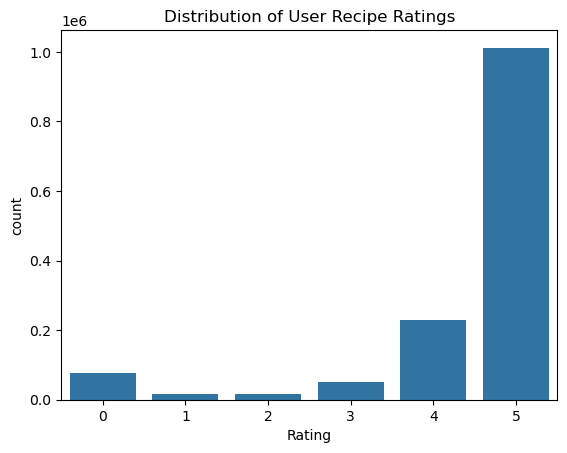

In [11]:
sns.countplot(data=ratings, x='Rating')
plt.title("Distribution of User Recipe Ratings")
plt.show()

In [9]:
filtered_data = ratings.groupby('AuthorId').filter(lambda x: len(x) >= 5)
filtered_data.head()

,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17T16:49:59Z,2001-10-17T16:49:59Z
2,9,4523,2046,Gay Gilmore ckpt,2,i think i did something wrong because i could ...,2000-02-25T09:00:00Z,2000-02-25T09:00:00Z
3,13,7435,1773,Malarkey Test,5,easily the best i have ever had. juicy flavor...,2000-03-13T21:15:00Z,2000-03-13T21:15:00Z
5,17,5221,2046,Gay Gilmore ckpt,4,"love it, but without the bean sprouts.",2000-05-08T11:08:00Z,2000-05-08T11:08:00Z
6,19,13307,2046,Gay Gilmore ckpt,5,"chewy goodness, not crispy at all. i even thre...",2000-05-21T16:59:00Z,2000-05-21T16:59:00Z


In [13]:
filtered_data['AuthorId'].value_counts()

AuthorId
424680     8842
37449      6605
383346     5438
128473     4693
169430     4586
           ... 
49859         5
597280        5
626439        5
919608        5
1624670       5
Name: count, Length: 27683, dtype: int64

In [14]:
filtered_data['AuthorId'].nunique()

27683

In [15]:
ratings['RecipeId'].nunique()

271678

In [16]:
filtered_data['RecipeId'].nunique()

249216

In [17]:
(27683 / 271907) * 100

10.181054551740116

In [18]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1089887 entries, 1 to 1401971
Data columns (total 8 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   ReviewId       1089887 non-null  int64 
 1   RecipeId       1089887 non-null  int64 
 2   AuthorId       1089887 non-null  int64 
 3   AuthorName     1089887 non-null  object
 4   Rating         1089887 non-null  int64 
 5   Review         1089880 non-null  object
 6   DateSubmitted  1089887 non-null  object
 7   DateModified   1089887 non-null  object
dtypes: int64(4), object(4)
memory usage: 74.8+ MB


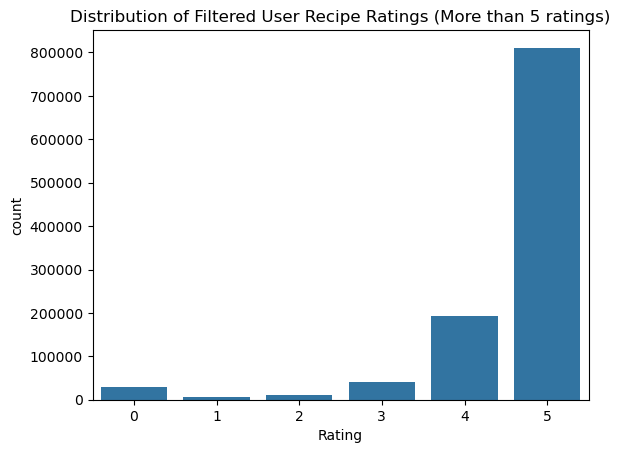

In [19]:
sns.countplot(data=filtered_data, x='Rating')
plt.title("Distribution of Filtered User Recipe Ratings (More than 5 ratings)")
plt.show()

## Dataset Building

In this section we will be creating a dataset that is in a format that can be utilized with the Lenskit Package. We will be focusing mainly on Explicit ratings for this dataset.

In [10]:
dataset = from_interactions_df(df=filtered_data, user_col = 'AuthorId', item_col = 'RecipeId', 
                               rating_col= 'Rating', timestamp_col= 'DateSubmitted')

In [11]:
dataset

<Dataset {
  item: 249,216,
  user: 27,683,
  rating: 1,089,887,
}

In [12]:
# Now to save the dataset to be used later in the analysis
dataset.save("../data/cleaned_data/recipe_dataset")

Testing to see if the dataset would load

In [13]:
ratings_data = Dataset.load('../data/cleaned_data/recipe_dataset')
ratings_data

<Dataset {
  item: 249,216,
  user: 27,683,
  rating: 1,089,887,
}